# Asymmetry sweep

Sweep the ratio between the two qubits' asymmetry factors and record the eigenbasis populations at the end of ramp 1. Looking for ratios where the populations are roughly uniform across all eigenstates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qutip as qt

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment

## Parameters

In [15]:
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

epsilon = 1
ramp_time = 1
dt = 0.1
sample_wait = 0

# Bell-state example, matching LSZ_main.ipynb
local_z_list = np.array([1, 1])
local_x_list = np.array([1, 1])
zz_terms     = np.array([4])
n_qubits     = len(local_z_list)

# psi_p = 1/np.sqrt(2)*qt.tensor([ket1, ket0]) + 1/np.sqrt(2)*qt.tensor([ket0, ket1])
# psi_m = 1/np.sqrt(2)*qt.tensor([ket1, ket0]) - 1/np.sqrt(2)*qt.tensor([ket0, ket1])
# psi0  = 0.5*(qt.tensor([ket0, ket0]) + psi_p + psi_m + qt.tensor([ket1, ket1]))

psi0 = qt.tensor([1/np.sqrt(2)*(ket0 + ket1)]*n_qubits)
#psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1),1/np.sqrt(2)*(ket0 + ket1)])

H_target_dict = {'local_z': local_z_list, 'local_x': local_x_list, 'two_body': zz_terms}

# Sweep: qubit 0 fixed at 1, qubit 1 scanned from 1 to 10.
ratios = np.arange(1.0, 10.0 + 1e-9, 0.25)
print(f'{len(ratios)} sweep points from {ratios[0]} to {ratios[-1]}')

37 sweep points from 1.0 to 10.0


## Sweep

In [16]:
n_states = 2**n_qubits
pops_end_r1 = np.zeros((len(ratios), n_states))

for i, r in enumerate(ratios):
    assym = [1.0, float(r)]
    evo = LSZ_experiment(n_qubits, epsilon, H_target_dict, ramp_time, sample_wait, dt,
                         assymetry_factors=assym, initial_state=psi0)
    sim_r1, _, _ = evo.time_evolution()
    pops_r1 = evo.calculate_eigenbasis_populations(sim_r1)
    pops_end_r1[i] = pops_r1[-1]

print('Done.')

Done.


## Populations vs asymmetry ratio

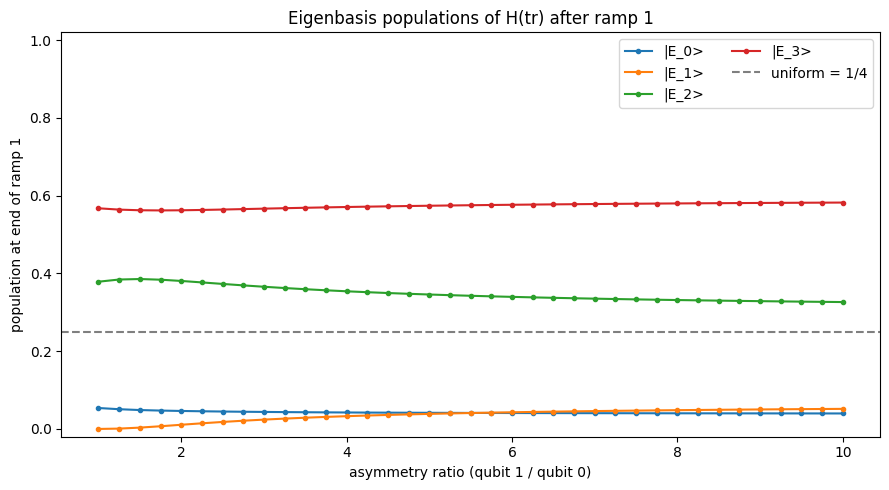

[0.03982961 0.05164167 0.32631463 0.58221408]


In [17]:
uniform = 1.0 / n_states

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(n_states):
    ax.plot(ratios, pops_end_r1[:, k], marker='o', markersize=3, label=f'|E_{k}>')
ax.axhline(uniform, color='k', linestyle='--', alpha=0.5, label=f'uniform = 1/{n_states}')
ax.set_xlabel('asymmetry ratio (qubit 1 / qubit 0)')
ax.set_ylabel('population at end of ramp 1')
ax.set_title('Eigenbasis populations of H(tr) after ramp 1')
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

print(pops_end_r1[-1])

## How close to uniform?

Standard deviation of the four populations at each ratio — small values mean all eigenstates are populated similarly.

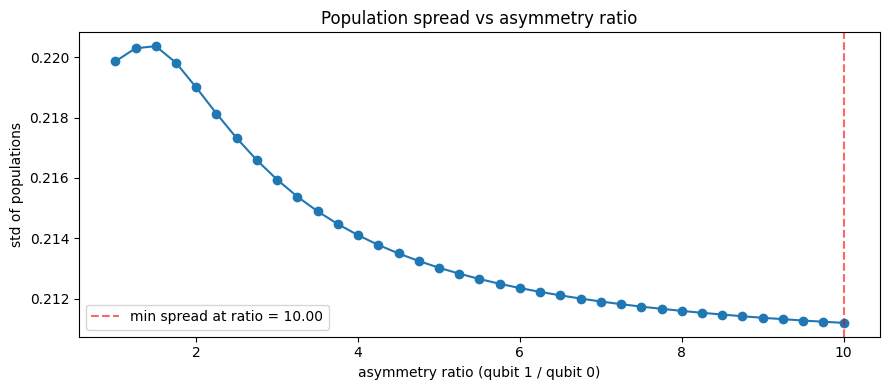

Most uniform at ratio 10.00:
  populations = [0.05476045 0.04946856 0.34353247 0.55223853]
  std         = 0.2112


In [5]:
spread = pops_end_r1.std(axis=1)
best_idx = int(np.argmin(spread))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ratios, spread, marker='o')
ax.axvline(ratios[best_idx], color='r', linestyle='--', alpha=0.6,
           label=f'min spread at ratio = {ratios[best_idx]:.2f}')
ax.set_xlabel('asymmetry ratio (qubit 1 / qubit 0)')
ax.set_ylabel('std of populations')
ax.set_title('Population spread vs asymmetry ratio')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Most uniform at ratio {ratios[best_idx]:.2f}:')
print(f'  populations = {pops_end_r1[best_idx]}')
print(f'  std         = {spread[best_idx]:.4f}')